# Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa
**Section:** 3CSE | **Group:** 5

**Members and Contributions:**

| Name | Role | Contribution |
|---|---|---|
| Jodimeer A. Ammang | XLM-R Person | Fine-tuning XLM-RoBERTa (Notebook 03), comparison analysis (Notebook 04), Sections 4.2, 5.3, 5.4, 6.2, 6.3, 7, 8; contributed to manuscript integration and discussion writing |
| Joaquim Cruz | Classical Model Lead | Naive Bayes implementation (Notebook 02), data pipeline and EDA (Notebook 01), Sections 4.1, 5.1, 5.2, 6.1; contributed to dataset documentation and phenomenon slice construction |
| Dan Angelo Erasquin | Manuscript Lead | Manuscript structure, writing, and editorial integration across all sections; contributed to comparison analysis and results interpretation |
| Justin Floro | Data & EDA Lead | Dataset acquisition, preprocessing pipeline, EDA visualizations, phenomenon slice definitions; contributed to implementation documentation |


---
# NOTEBOOK 01 — Data & EDA
---

# 01 - Data Pipeline & EDA for Taglish Sentiment Classification

**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa

**Notebook owner:** Justin Floro (Data Person)

**Role:** Load FiReCS, produce `firecs_processed.csv`, generate EDA figures, and build phenomenon slices for comparison analysis.

## 0. Setup
Mount Google Drive, configure shared paths, and install dependencies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

DRIVE_BASE     = "/content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project"
DATA_TRAIN     = f"{DRIVE_BASE}/data/FiReCS_train_set.csv"
DATA_TEST      = f"{DRIVE_BASE}/data/FiReCS_test_set.csv"
DATA_PROCESSED = f"{DRIVE_BASE}/data/firecs_processed.csv"
OUTPUTS        = f"{DRIVE_BASE}/outputs"
FIGURES        = f"{DRIVE_BASE}/outputs/figures"
CHECKPOINTS = f"{DRIVE_BASE}/checkpoints/xlmr-finetuned"
HF_CACHE    = f"{DRIVE_BASE}/cache"

os.makedirs(CHECKPOINTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)
os.environ["TRANSFORMERS_CACHE"] = HF_CACHE
os.environ["HF_HOME"]            = HF_CACHE

print("Paths set. Drive base:", DRIVE_BASE)

Paths set. Drive base: /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project


In [ ]:
!pip install pandas matplotlib seaborn scikit-learn transformers datasets bertviz statsmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.4 MB/s eta 0:00:00


## 1. Load Raw Data
Load FiReCS train and test CSVs, inspect schema, label distribution, and class balance.
Expected: 7,340 train rows / 3,147 test rows, columns: `review`, `label`.

In [ ]:
import pandas as pd

train_df = pd.read_csv(DATA_TRAIN)
test_df  = pd.read_csv(DATA_TEST)

print("TRAIN shape:", train_df.shape)
print("TEST shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nDtypes:\n", train_df.dtypes)
print("\nTRAIN sample:")
display(train_df.head(3))
print("\nTRAIN label distribution:\n", train_df.iloc[:, -1].value_counts())
print("\nTEST label distribution:\n",  test_df.iloc[:, -1].value_counts())

TRAIN shape: (7340, 2)
TEST shape: (3147, 2)

Columns: ['review', 'label']

Dtypes:
 review     object
label     float64
dtype: object

TRAIN sample:


,review,label
0,im very disappointed kasi di gumana ang dalawa...,0.0
1,10 10 it has minor damage when it was delivere...,1.0
2,super ganda then tama ung size and color sa uu...,2.0



TRAIN label distribution:
 label
1.0    2549
2.0    2410
0.0    2381
Name: count, dtype: int64

TEST label distribution:
 label
1.0    1087
2.0    1033
0.0    1027
Name: count, dtype: int64


## 2. Label Encoding and Merge
Convert float labels to int (0=Negative, 1=Neutral, 2=Positive), add split column,
merge into one `firecs_processed.csv`. Saving this file unblocks Person 2 (NB) and Person 3 (XLM-R).

In [ ]:
# Convert labels from float to int (0.0 → 0, 1.0 → 1, 2.0 → 2)
train_df['label'] = train_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

# Add split column to track origin after merging
train_df['split'] = 'train'
test_df['split']  = 'test'

# Merge into one processed file
processed = pd.concat([train_df, test_df], ignore_index=True)

# Save to shared Drive folder
processed.to_csv(DATA_PROCESSED, index=False)

# Confirm
print(f"Saved to: {DATA_PROCESSED}")
print(f"Total rows: {len(processed)}")
print(f"\nRows per split:\n{processed['split'].value_counts()}")
print(f"\nLabel distribution (full):\n{processed['label'].value_counts().sort_index()}")

Saved to: /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/data/firecs_processed.csv
Total rows: 10487

Rows per split:
split
train    7340
test     3147
Name: count, dtype: int64

Label distribution (full):
label
0    3408
1    3636
2    3443
Name: count, dtype: int64


## 3. EDA — Class Distribution and Review Length
Visualize class balance across train and test splits and review length distribution by class.
Figures saved to `outputs/figures/`.

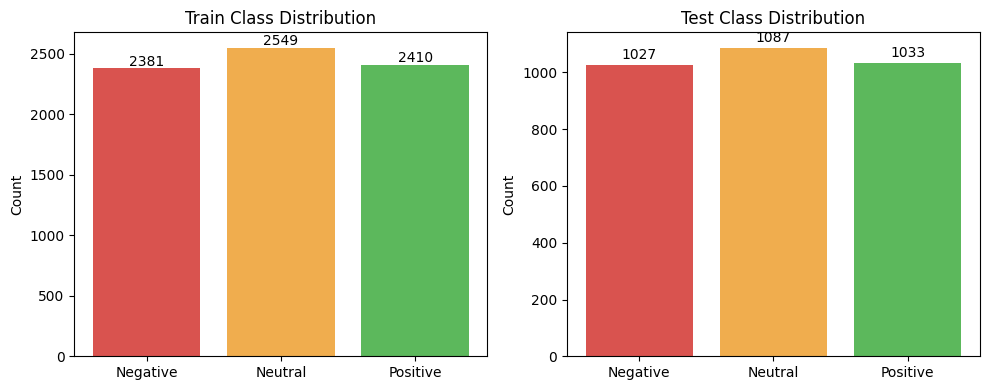

Saved: eda_class_distribution.png


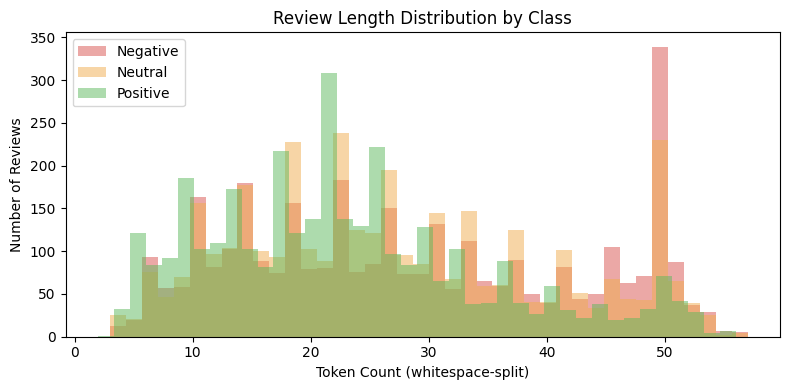

Saved: eda_length_distribution.png

Token count stats by class:
        count  mean   std  min   25%   50%   75%   max
label                                                 
0      3408.0  28.9  14.2  3.0  16.0  27.0  42.0  57.0
1      3636.0  27.1  13.0  3.0  17.0  25.0  37.0  57.0
2      3443.0  23.0  11.8  2.0  14.0  22.0  29.0  56.0


In [ ]:
import matplotlib.pyplot as plt

# --- Plot 1: Class distribution by split ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

for ax, (split_name, split_df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = split_df['label'].value_counts().sort_index()
    ax.bar([label_names[i] for i in counts.index], counts.values, color=['#d9534f','#f0ad4e','#5cb85c'])
    ax.set_title(f'{split_name} Class Distribution')
    ax.set_ylabel('Count')
    # Annotate bar counts
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_class_distribution.png", dpi=150)
plt.show()
print("Saved: eda_class_distribution.png")


# --- Plot 2: Review length distribution by class ---
processed['token_count'] = processed['review'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(8, 4))
colors = {0: '#d9534f', 1: '#f0ad4e', 2: '#5cb85c'}

for label_val, label_name in label_names.items():
    subset = processed[processed['label'] == label_val]['token_count']
    ax.hist(subset, bins=40, alpha=0.5, label=label_name, color=colors[label_val])

ax.set_title('Review Length Distribution by Class')
ax.set_xlabel('Token Count (whitespace-split)')
ax.set_ylabel('Number of Reviews')
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_length_distribution.png", dpi=150)
plt.show()
print("Saved: eda_length_distribution.png")


# --- Summary stats: token counts per class ---
print("\nToken count stats by class:")
print(processed.groupby('label')['token_count'].describe().round(1))

In [ ]:
import pandas as pd

# Load processed data and isolate test set
processed = pd.read_csv(DATA_PROCESSED)
test_df = processed[processed['split'] == 'test'].reset_index(drop=True)

# Add token count column for short/long slices
test_df['token_count'] = test_df['review'].apply(lambda x: len(str(x).split()))

print(f"Test set: {len(test_df)} rows")
print(test_df.head(3))

Test set: 3147 rows
                                              review  label split  token_count
0  okay naman kaso maliit size e adjust nyona lan...      1  test           13
1  good seller sends out photo before shipping ma...      2  test           27
2  di cya gano kabilis sa net loading and loading...      1  test           14


## 4. Phenomenon Slices
Filter the test set into linguistic subsets for the comparison analysis in Notebook 04.
Slices cover: pragmatic markers (naman, lang, pa, na), slang (awit), negation (hindi, di, wala),
review length (short <10 tokens, long >50 tokens), and code-switching density (high/low CS).
Saved to `outputs/phenomenon_slices.csv`.

In [ ]:
# Build phenomenon slices from test set
slices = []

# --- Pragmatic markers (individual slices per marker) ---
for marker in ['naman', 'lang', 'pa', 'na']:
    subset = test_df[test_df['review'].str.contains(rf'\b{marker}\b', regex=True)].copy()
    subset['slice_name'] = f'marker_{marker}'
    slices.append(subset)

# --- Slang ---
for slang in ['awit']:
    subset = test_df[test_df['review'].str.contains(rf'\b{slang}\b', regex=True)].copy()
    subset['slice_name'] = f'slang_{slang}'
    slices.append(subset)

# --- Negation ---
for neg in ['hindi', 'di', 'wala']:
    subset = test_df[test_df['review'].str.contains(rf'\b{neg}\b', regex=True)].copy()
    subset['slice_name'] = f'negation_{neg}'
    slices.append(subset)

# --- Review length ---
short = test_df[test_df['token_count'] < 10].copy()
short['slice_name'] = 'short_reviews'
slices.append(short)

long = test_df[test_df['token_count'] > 50].copy()
long['slice_name'] = 'long_reviews'
slices.append(long)

# --- Code-switching density ---
# Proxy: load a basic English word list, count non-English tokens as Filipino
english_words = set([
    'the','a','an','is','are','was','were','i','you','he','she','it','we','they',
    'my','your','his','her','our','their','this','that','these','those','and','or',
    'but','so','if','in','on','at','to','for','of','with','from','by','as','not',
    'have','has','had','do','does','did','be','been','being','will','would','can',
    'could','should','may','might','must','shall','very','just','also','more','good',
    'great','nice','well','bad','really','all','no','yes','ok','okay','so','get',
    'got','like','love','need','want','use','go','come','see','know','think','make',
    'order','ordered','product','item','seller','shop','shipping','delivery','quality',
    'price','size','color','color','received','recommend','highly','would','worth'
])

def cs_density(text):
    # Returns ratio of non-English tokens (proxy for Filipino tokens)
    tokens = str(text).lower().split()
    if len(tokens) == 0:
        return 0
    filipino_count = sum(1 for t in tokens if t not in english_words)
    return filipino_count / len(tokens)

test_df['cs_density'] = test_df['review'].apply(cs_density)

high_cs = test_df[test_df['cs_density'] > 0.5].copy()
high_cs['slice_name'] = 'high_cs'
slices.append(high_cs)

low_cs = test_df[test_df['cs_density'] <= 0.5].copy()
low_cs['slice_name'] = 'low_cs'
slices.append(low_cs)

# --- Combine and save ---
phenomenon_df = pd.concat(slices, ignore_index=True)
phenomenon_df = phenomenon_df[['review', 'label', 'slice_name']]
phenomenon_df.to_csv(f"{OUTPUTS}/phenomenon_slices.csv", index=False)

print(f"Saved: phenomenon_slices.csv")
print(f"\nSlice sizes:")
print(phenomenon_df['slice_name'].value_counts().sort_index())

Saved: phenomenon_slices.csv

Slice sizes:
slice_name
high_cs           3050
long_reviews       111
low_cs              97
marker_lang        899
marker_na         1427
marker_naman       765
marker_pa          554
negation_di        440
negation_hindi     543
negation_wala      213
short_reviews      256
slang_awit           5
Name: count, dtype: int64


---
# NOTEBOOK 02 - Naive Bayes
---

# 02 - Naive Bayes Classifier for Taglish Sentiment Classification
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa

**Notebook owner:** Joaquim Cruz (NB Person)

**Role:** Train and evaluate a Multinomial Naive Bayes classifier on FiReCS. Extract top features per class and produce `nb_predictions.csv` for the comparison notebook.


## 0. Setup
Mount Google Drive, configure shared paths, and install dependencies.

## 1. Load Processed Data
Load `firecs_processed.csv` produced by Notebook 01.
Separate train and test splits — test set is not touched until final evaluation.

In [ ]:
import pandas as pd

# Load the processed dataset produced by notebook 01
processed = pd.read_csv(DATA_PROCESSED)

# Separate train and test splits
train_df = processed[processed['split'] == 'train'].reset_index(drop=True)
test_df  = processed[processed['split'] == 'test'].reset_index(drop=True)

# Confirm
print("Train:", len(train_df), "| Test:", len(test_df))
print("Columns:", processed.columns.tolist())
print("\nSample:")
display(train_df.head(3))

Train: 7340 | Test: 3147
Columns: ['review', 'label', 'split']

Sample:


,review,label,split
0,im very disappointed kasi di gumana ang dalawa...,0,train
1,10 10 it has minor damage when it was delivere...,1,train
2,super ganda then tama ung size and color sa uu...,2,train


## 2. TF-IDF Pipeline and Hyperparameter Sweep
Build TF-IDF vectorizer fitted on train only (no leakage).
Sweep alpha ∈ {0.01, 0.1, 0.5, 1.0} × ngram_range ∈ {(1,1), (1,2)}.
Best config selected on a 10% validation hold-out from the training set.

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Fix seed for reproducibility
RANDOM_STATE = 42

# Carve out a 10% validation set from train (for hyperparameter selection)
# Test set is untouched until final evaluation
X_train_full = train_df['review']
y_train_full = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=RANDOM_STATE, stratify=y_train_full
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(test_df)}")

# Hyperparameter grid
alphas      = [0.01, 0.1, 0.5, 1.0]
ngram_ranges = [(1,1), (1,2)]

results = []

for ngram in ngram_ranges:
    # Fit TF-IDF on train only, transform val — no leakage
    tfidf = TfidfVectorizer(ngram_range=ngram, min_df=2)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf   = tfidf.transform(X_val)

    for alpha in alphas:
        nb = MultinomialNB(alpha=alpha)
        nb.fit(X_train_tfidf, y_train)
        preds = nb.predict(X_val_tfidf)

        acc = accuracy_score(y_val, preds)
        f1  = f1_score(y_val, preds, average='weighted')

        results.append({
            'ngram_range': ngram,
            'alpha': alpha,
            'val_accuracy': round(acc, 4),
            'val_f1': round(f1, 4)
        })
        print(f"ngram={ngram} | alpha={alpha} | acc={acc:.4f} | f1={f1:.4f}")

# Find best config by weighted F1
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nBest config:\n{best}")

Train: 6606 | Val: 734 | Test: 3147
ngram=(1, 1) | alpha=0.01 | acc=0.7411 | f1=0.7436
ngram=(1, 1) | alpha=0.1 | acc=0.7793 | f1=0.7813
ngram=(1, 1) | alpha=0.5 | acc=0.7984 | f1=0.8001
ngram=(1, 1) | alpha=1.0 | acc=0.7888 | f1=0.7907
ngram=(1, 2) | alpha=0.01 | acc=0.7561 | f1=0.7583
ngram=(1, 2) | alpha=0.1 | acc=0.7984 | f1=0.7994
ngram=(1, 2) | alpha=0.5 | acc=0.8052 | f1=0.8065
ngram=(1, 2) | alpha=1.0 | acc=0.8011 | f1=0.8027

Best config:
ngram_range     (1, 2)
alpha              0.5
val_accuracy    0.8052
val_f1          0.8065
Name: 6, dtype: object


## 3. Final Model Training and Evaluation
Retrain best config (ngram=(1,2), α=0.5) on the full training set.
Evaluate on the held-out test set: accuracy, weighted F1, per-class P/R/F1, confusion matrix.

Test Accuracy: 0.7909
Test Weighted F1: 0.7928

Per-class report:
              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79      1027
     Neutral       0.69      0.76      0.72      1087
    Positive       0.89      0.85      0.87      1033

    accuracy                           0.79      3147
   macro avg       0.80      0.79      0.79      3147
weighted avg       0.80      0.79      0.79      3147



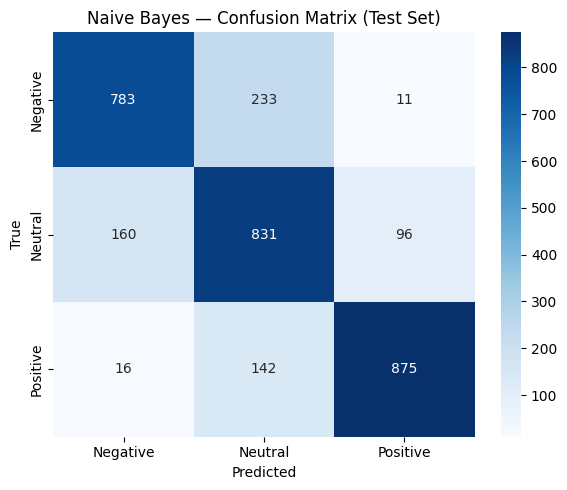

Saved: nb_confusion_matrix.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train final model on full train set using best config
tfidf_final = TfidfVectorizer(ngram_range=(1,2), min_df=2)
X_train_final = tfidf_final.fit_transform(X_train_full)  # full train, no val holdout
X_test_final  = tfidf_final.transform(test_df['review'])  # transform test

y_test = test_df['label']

nb_final = MultinomialNB(alpha=0.5)
nb_final.fit(X_train_final, y_train_full)

# Final predictions on test set
nb_preds = nb_final.predict(X_test_final)

# --- Metrics ---
acc = accuracy_score(y_test, nb_preds)
f1  = f1_score(y_test, nb_preds, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Weighted F1: {f1:.4f}")
print(f"\nPer-class report:")
print(classification_report(y_test, nb_preds, target_names=['Negative','Neutral','Positive']))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, nb_preds)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'], ax=ax)
ax.set_title('Naive Bayes — Confusion Matrix (Test Set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f"{FIGURES}/nb_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: nb_confusion_matrix.png")

## 4. Top Features per Class
Extract top 20 discriminative tokens per class using log-likelihood ratio:
log P(token|class) − max log P(token|other classes).
This is the key interpretability artifact for RQ4a.


--- Negative ---
  sayang pera               2.8050
  so disappointed           2.5840
  nakaka disappoint         2.3977
  not satisfied             2.3681
  very disappointed         2.3116
  wag kayo                  2.2709
  scammer                   2.2422
  poor quality              2.1545
  panget                    2.1497
  waste of                  2.1090
  lang pera                 2.0964
  disappointed              2.0881
  not recommend             2.0600
  poor                      2.0293
  wag na                    2.0280
  not order                 2.0264
  binigay nyo               1.9900
  kwenta                    1.9791
  nakakadismaya             1.9781
  waste                     1.9745

--- Neutral ---
  kaso may                  2.0612
  kaso yung                 2.0215
  siya kaso                 1.9693
  kaso maliit               1.9575
  naman kaso                1.8671
  kaso ang                  1.8067
  size pero                 1.7137
  dumating pero     

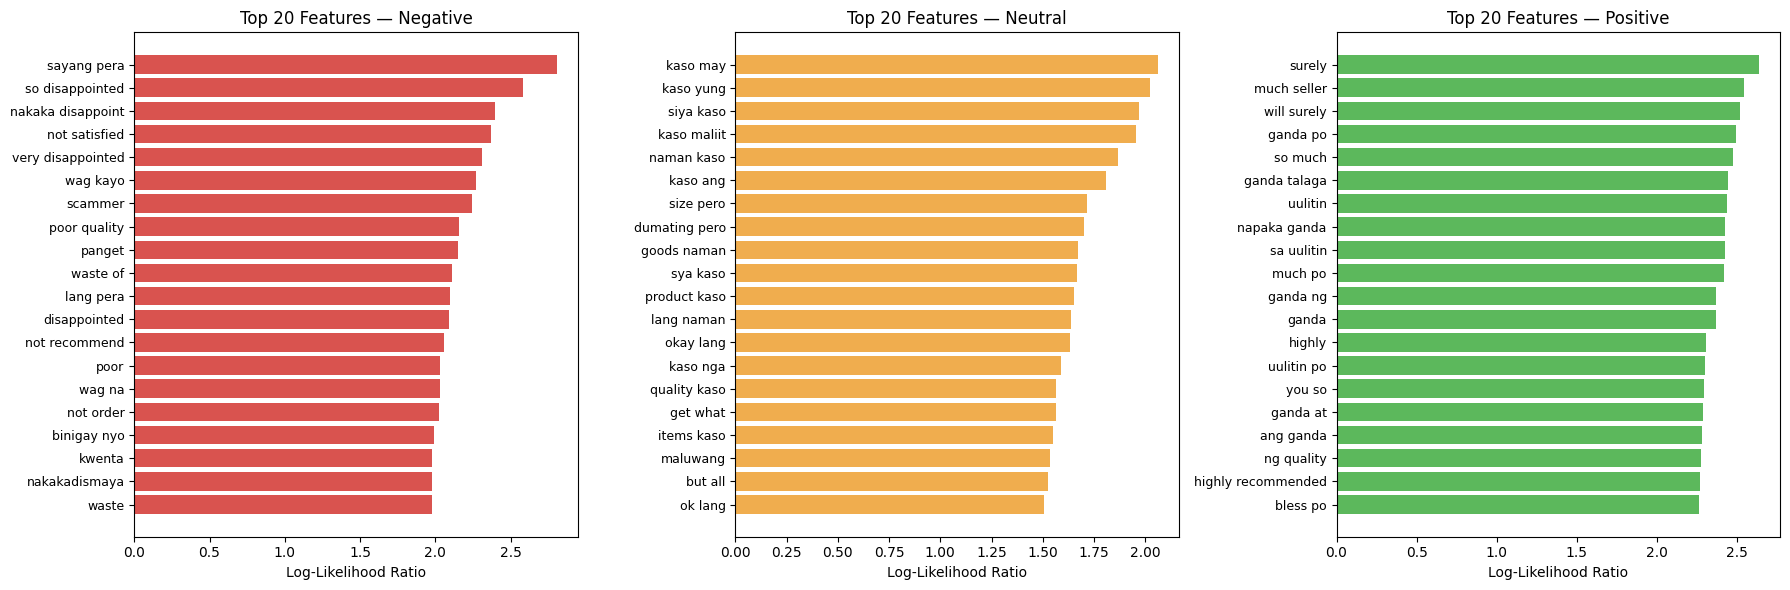


Saved: nb_top_features.png


In [ ]:
# Extract top 20 features per class by log-likelihood ratio
import numpy as np

# Log probability of each token given each class
log_probs = nb_final.feature_log_prob_  # shape: (3, vocab_size)
feature_names = np.array(tfidf_final.get_feature_names_out())

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
top_k = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for class_idx, class_name in label_names.items():
    # Score = log P(token|class) - max log P(token|other classes)
    other_classes = [i for i in range(3) if i != class_idx]
    log_ratio = log_probs[class_idx] - np.max(log_probs[other_classes], axis=0)

    # Get top k tokens
    top_indices = np.argsort(log_ratio)[-top_k:][::-1]
    top_tokens  = feature_names[top_indices]
    top_scores  = log_ratio[top_indices]

    # Plot
    ax = axes[class_idx]
    ax.barh(range(top_k), top_scores[::-1], color=['#d9534f','#f0ad4e','#5cb85c'][class_idx])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_tokens[::-1], fontsize=9)
    ax.set_title(f'Top {top_k} Features — {class_name}')
    ax.set_xlabel('Log-Likelihood Ratio')

    # Print to console too
    print(f"\n--- {class_name} ---")
    for token, score in zip(top_tokens, top_scores):
        print(f"  {token:<25} {score:.4f}")

plt.tight_layout()
plt.savefig(f"{FIGURES}/nb_top_features.png", dpi=150)
plt.show()
print("\nSaved: nb_top_features.png")

## 5. Predictions Export
Save `nb_predictions.csv` to outputs/ — required input for Notebook 04 (comparison analysis).
Columns: text, true_label, nb_pred, nb_correct.

In [ ]:
# Save predictions for use in notebook 04 (comparison analysis)
nb_output = test_df[['review', 'label']].copy()
nb_output.columns = ['text', 'true_label']
nb_output['nb_pred']    = nb_preds
nb_output['nb_correct'] = (nb_output['nb_pred'] == nb_output['true_label']).astype(int)

nb_output.to_csv(f"{OUTPUTS}/nb_predictions.csv", index=False)

print(f"Saved: nb_predictions.csv")
print(f"Rows: {len(nb_output)}")
print(f"\nOverall NB accuracy check: {nb_output['nb_correct'].mean():.4f}")
print(f"\nSample:\n")
display(nb_output.head(3))

Saved: nb_predictions.csv
Rows: 3147

Overall NB accuracy check: 0.7909

Sample:



,text,true_label,nb_pred,nb_correct
0,okay naman kaso maliit size e adjust nyona lan...,1,1,1
1,good seller sends out photo before shipping ma...,2,1,0
2,di cya gano kabilis sa net loading and loading...,1,1,1


## 6. Error Analysis - Pragmatic Marker Misclassifications
Identify misclassified reviews containing target pragmatic markers and slang:
naman, lang, pa, na, awit. For each case: examine top NB features and explain
why the bag-of-words representation failed. Findings feed into the Discussion section.

In [ ]:
# Build a dataframe of misclassified reviews for error analysis
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
feature_names = np.array(tfidf_final.get_feature_names_out())
log_probs = nb_final.feature_log_prob_

# All misclassified reviews
errors_df = test_df.copy()
errors_df['nb_pred'] = nb_preds
errors_df['correct'] = (errors_df['label'] == errors_df['nb_pred'])
errors_df = errors_df[errors_df['correct'] == False].reset_index(drop=True)

print(f"Total misclassified: {len(errors_df)}")

# Filter for reviews containing target pragmatic markers and slang
target_tokens = ['naman', 'lang', 'pa', 'na', 'awit']
pattern = '|'.join([rf'\b{t}\b' for t in target_tokens])
marker_errors = errors_df[errors_df['review'].str.contains(pattern, regex=True)].reset_index(drop=True)

print(f"Misclassified reviews containing target tokens: {len(marker_errors)}")
print()

# Show top 10 for manual inspection
for i, row in marker_errors.head(10).iterrows():
    print(f"[{i+1}] TRUE: {label_names[row['label']]} | PRED: {label_names[row['nb_pred']]}")
    print(f"     Review: {row['review'][:120]}")

    # Show which target tokens are present
    found = [t for t in target_tokens if f' {t} ' in f" {row['review']} "]
    print(f"     Target tokens found: {found}")

    # Show top NB features for this review
    tfidf_vec = tfidf_final.transform([row['review']])
    nonzero_idx = tfidf_vec.nonzero()[1]
    pred_class = row['nb_pred']
    scores = [(feature_names[j], log_probs[pred_class][j]) for j in nonzero_idx]
    top_features = sorted(scores, key=lambda x: x[1], reverse=True)[:5]
    print(f"     Top NB features (for predicted class {label_names[pred_class]}): {top_features}")
    print()

Total misclassified: 658
Misclassified reviews containing target tokens: 465

[1] TRUE: Positive | PRED: Neutral
     Review: good seller sends out photo before shipping mabilis din nadeliver sakin makapal un cloth ng panty ska may boning sya sa 
     Target tokens found: ['na']
     Top NB features (for predicted class Neutral): [('na', np.float64(-5.794657184691181)), ('sa', np.float64(-5.927717364245715)), ('sya', np.float64(-6.151884395390846)), ('ng', np.float64(-6.330550057999299)), ('may', np.float64(-6.617545172975172))]

[2] TRUE: Positive | PRED: Neutral
     Review: ang ganda its legit orig naka seal at may tag yung packaging is may butas yun lang naman pero di naman napano yung bag s
     Target tokens found: ['naman', 'lang']
     Top NB features (for predicted class Neutral): [('yung', np.float64(-5.679284867969819)), ('naman', np.float64(-5.765218552484164)), ('lang', np.float64(-5.792954343974564)), ('pero', np.float64(-5.91227540027875)), ('ang', np.float64(-6.09428624

## Error Analysis — NB Misclassifications on Pragmatic Marker Reviews

### Case 1 (Review 2): TRUE=Positive → PRED=Neutral
Review: "ang ganda its legit orig naka seal at may tag yung packaging is may butas yun lang naman pero di naman napano yung bag"

The review is clearly positive — "ang ganda", "legit orig", "naka seal" are strong positive signals.
However, NB's top features for Neutral are dominated by **naman** and **lang**, which frequently
co-occur in neutral contrastive reviews (e.g., "okay lang naman"). Here, both particles appear
in a concessive clause ("may butas yun lang naman pero...") that actually MINIMIZES a flaw,
not signals neutrality. NB cannot distinguish this pragmatic use of naman+lang from its
literal neutral co-occurrence pattern — it sees the tokens, not the function.

---

### Case 2 (Review 3): TRUE=Neutral → PRED=Negative
Review: "hindi man magic tape yung na receive ko tape lang sya yung first order ko naman yung may magic tape yung binigay"

The reviewer received the wrong item but is not expressing strong negative sentiment —
the tone is matter-of-fact. NB misclassifies this as Negative because **hindi** is a strong
negative feature (it means "not/no" in Filipino) and pulls the prediction toward Negative.
The particle **naman** in "first order ko naman" is used here as a contrastive discourse marker
("but my first order had it"), not a sentiment carrier. NB has no way to model this
pragmatic contrast — it simply accumulates the negative weight of "hindi".

---

### Case 3 (Review 6): TRUE=Positive → PRED=Neutral
Review: "sana gumana ok lang naman itsura pero diko nasubukan chinarge ko muna medyo matagal delivery pero sana worth it"

This is a weak positive — the reviewer hasn't tested the product yet but is hopeful ("sana
worth it"). NB latches onto **naman**, **lang**, and **pero** (all strong Neutral features from
the top features analysis) and misses the overall positive framing. This case shows NB's
sensitivity to surface token frequency: naman+lang+pero appear together often in neutral
reviews, so their co-occurrence here overrides weaker positive signals.

---

### Case 4 (Review 9): TRUE=Negative → PRED=Neutral
Review: "hindi na xa d same color sa first order q pangit na ang pagka light green nya at parang hindi na xa maxado madikit"

A clearly negative review — wrong color, poor quality. NB predicts Neutral because
**na** dominates the top features for both Neutral and Negative classes (log prob -5.79
vs -5.65). The particle **na** is extremely high-frequency and semantically ambiguous in
Taglish — it can mark aspect ("already"), emphasis, or discourse continuity. Its
ubiquity makes it a weak discriminator, yet it appears so frequently it drowns out
stronger negative signals like "pangit" (ugly). This is a vocabulary frequency artifact:
high-frequency function words pollute the feature space for ambiguous classes.

---

### Case 5 (Review 10): TRUE=Neutral → PRED=Negative
Review: "i ordered black variant pero purple yung dumating okay naman walang sira kaso sana inform naman nila yung buyer na wala"

A classic neutral review — wrong color delivered, but product is intact and the reviewer
is mildly dissatisfied, not angry. NB fires on **na** and **pero** as Negative features and
misses that "okay naman walang sira" (okay, no damage) explicitly expresses acceptance.
The phrase "okay naman" is exactly the kind of pragmatic softening that NB cannot process:
"okay" alone would push toward Positive, but "naman" here functions as a hedging particle
that signals qualified acceptance. Without modeling the naman-okay interaction, NB
misreads the review's overall sentiment.

---

### Summary of Failure Patterns

1. **naman + lang as false Neutral signals** — these particles dominate NB's Neutral
   feature space and misfire when used pragmatically (concession, hedging) rather than
   as simple co-occurrence patterns.

2. **hindi as a blunt Negative trigger** — NB treats "hindi" as a reliable negative signal
   but cannot distinguish negation-of-flaw ("hindi naman masama") from negation-of-positive.

3. **na as a noisy high-frequency feature** — extreme frequency makes "na" weakly
   discriminative but hard to ignore, polluting predictions for Neutral vs Negative.

4. **Concessive pero constructions** — "pero" reliably signals contrast in Taglish reviews,
   but NB cannot determine which side of the contrast carries the sentiment weight.

5. **Absence of sequence modeling** — all five cases involve a pragmatic marker whose
   effect depends on its position relative to a sentiment word. Bag-of-words discards
   this positional information entirely, which is the core structural limitation this
   analysis reveals.

---
# NOTEBOOK 03 - XLM-RoBERTa Fine-Tuning
---

# 03 - XLM-RoBERTa Fine-Tuning for Taglish Sentiment Classification
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa  
**Notebook owner:** Jodimeer Ammang (XLM-R Person)  
**Role:** Fine-tune `xlm-roberta-base` on FiReCS for 3-class sentiment classification.  

**First Part** Verify data pipeline, tokenizer, model loading, and sanity-check the forward pass.  
**Second Part** Full fine-tuning (2 epochs), evaluation, attention visualization.

## 1. Load Processed Data
Load `firecs_processed.csv` produced by the Data person (Notebook 01).  
Expected columns: `text`, `label`, `split` (train/test).

In [ ]:
import pandas as pd

df = pd.read_csv(DATA_PROCESSED)
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")
print(f"\nLabel distribution (overall):\n{df['label'].value_counts().sort_index()}")
print(f"\nLabel distribution by split:")
print(df.groupby('split')['label'].value_counts().unstack(fill_value=0))
print(f"\nSample rows:")
df.head()

Total rows: 10487
Columns: ['review', 'label', 'split']

Split distribution:
split
train    7340
test     3147
Name: count, dtype: int64

Label distribution (overall):
label
0    3408
1    3636
2    3443
Name: count, dtype: int64

Label distribution by split:
label     0     1     2
split                  
test   1027  1087  1033
train  2381  2549  2410

Sample rows:


,review,label,split
0,im very disappointed kasi di gumana ang dalawa...,0,train
1,10 10 it has minor damage when it was delivere...,1,train
2,super ganda then tama ung size and color sa uu...,2,train
3,we like it po madali naming na receive and goo...,2,train
4,walang picture and video nung product wala kas...,2,train


## 2. Build HuggingFace Dataset & Tokenize
Tokenize with `xlm-roberta-base` SentencePiece tokenizer, max_length=128.  
This matches Cosme & De Leon (2024) protocol.

In [ ]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Log hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [ ]:
from datasets import Dataset, DatasetDict

train_df = df[df['split'] == 'train'][['review', 'label']].reset_index(drop=True)
test_df  = df[df['split'] == 'test'][['review', 'label']].reset_index(drop=True)

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test':  Dataset.from_pandas(test_df),
})

print(dataset)
print(f"\nTrain sample: {dataset['train'][0]}")

DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 7340
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 3147
    })
})

Train sample: {'review': 'im very disappointed kasi di gumana ang dalawa kung order', 'label': 0}


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE)

def tokenize_fn(batch):
    return tokenizer(batch['review'], padding='max_length', truncation=True, max_length=128)

tokenized = dataset.map(tokenize_fn, batched=True, batch_size=256)
tokenized = tokenized.remove_columns(['review'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

print(tokenized)
print(f"\nSample keys: {list(tokenized['train'][0].keys())}")
print(f"Input IDs shape: {tokenized['train'][0]['input_ids'].shape}")

Map:   0%|          | 0/7340 [00:00<?, ? examples/s]

Map:   0%|          | 0/3147 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 7340
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3147
    })
})

Sample keys: ['labels', 'input_ids', 'attention_mask']
Input IDs shape: torch.Size([128])


## 3. Load Model & Sanity Check
Load `xlm-roberta-base` with a 3-class classification head.  
Run a 2-batch forward pass to confirm loss decreases (sanity check).

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     278,045,955
Trainable parameters: 278,045,955


In [ ]:
from torch.utils.data import DataLoader

# Small dataloader for sanity check
sanity_loader = DataLoader(tokenized['train'].select(range(32)), batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
model.train()

print("Sanity check — 2 batches, loss should decrease:")
for i, batch in enumerate(sanity_loader):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch)
    loss = outputs.loss
    print(f"  Batch {i+1}: loss = {loss.item():.4f}")
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print("\n✓ Forward pass works. Loss decreasing confirms gradients flow correctly.")

Sanity check — 2 batches, loss should decrease:
  Batch 1: loss = 1.1241
  Batch 2: loss = 1.0485

✓ Forward pass works. Loss decreasing confirms gradients flow correctly.


---
## Full Fine-Tuning & Evaluation

In [ ]:
# Reinitialize model with fresh weights
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
)
model.to(device)
print("✓ Fresh model loaded for training.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Fresh model loaded for training.


In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average='weighted')
    precision, recall, f1_per, _ = precision_recall_fscore_support(labels, preds, average=None)
    return {
        'accuracy': acc,
        'f1_weighted': f1_weighted,
        'precision_neg': precision[0], 'recall_neg': recall[0], 'f1_neg': f1_per[0],
        'precision_neu': precision[1], 'recall_neu': recall[1], 'f1_neu': f1_per[1],
        'precision_pos': precision[2], 'recall_pos': recall[2], 'f1_pos': f1_per[2],
    }

training_args = TrainingArguments(
    output_dir=CHECKPOINTS,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    seed=SEED,
    fp16=True,
    report_to="none",
    load_best_model_at_end=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['test'],
    compute_metrics=compute_metrics,
)

print("✓ Trainer configured.")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Weight decay: {training_args.weight_decay}")

✓ Trainer configured.
  Epochs: 2
  Batch size: 16
  Learning rate: 2e-05
  Weight decay: 0.01


### 4. Train
This will take ~15-25 minutes on a T4 GPU. Keep the Colab tab active.  
Checkpoints are saved to Drive after each epoch as insurance.

In [ ]:
import time

start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

print(f"\n✓ Training complete in {train_time/60:.1f} minutes.")
print(f"  Final training loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Neg,Recall Neg,F1 Neg,Precision Neu,Recall Neu,F1 Neu,Precision Pos,Recall Pos,F1 Pos
1,0.502437,0.539349,0.797267,0.793766,0.853095,0.791626,0.821212,0.765328,0.666053,0.712248,0.778846,0.940949,0.852258
2,0.407283,0.437138,0.830632,0.831876,0.869474,0.804284,0.835610,0.739277,0.808648,0.772408,0.901786,0.879961,0.890740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Training complete in 6.6 minutes.
  Final training loss: 0.5505


### 5. Evaluate on Test Set
Report accuracy, weighted F1, per-class precision/recall/F1, and confusion matrix.  
**Replication target:** Cosme & De Leon (2024) report 0.84 accuracy - we should land within ~1 point.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
predictions = trainer.predict(tokenized['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

label_names = ['Negative', 'Neutral', 'Positive']

# Classification report
print("=" * 60)
print("XLM-RoBERTa — Test Set Results")
print("=" * 60)
report = classification_report(labels, preds, target_names=label_names, digits=4)
print(report)

acc = accuracy_score(labels, preds)
f1_w = f1_score(labels, preds, average='weighted')
print(f"Accuracy:    {acc:.4f}")
print(f"Weighted F1: {f1_w:.4f}")

# Replication check
print("\n" + "-" * 60)
cosme_acc = 0.84
diff = abs(acc - cosme_acc)
status = "✓ PASS" if diff <= 0.02 else "✗ INVESTIGATE"
print(f"Replication check vs. Cosme & De Leon (2024):")
print(f"  Ours: {acc:.4f}   Theirs: {cosme_acc}   Δ = {diff:.4f}   [{status}]")
if diff > 0.02:
    print("  ⚠ Gap > 2 points. Audit preprocessing, tokenizer, lr, and seed before proceeding.")

XLM-RoBERTa — Test Set Results
              precision    recall  f1-score   support

    Negative     0.8695    0.8043    0.8356      1027
     Neutral     0.7393    0.8086    0.7724      1087
    Positive     0.9018    0.8800    0.8907      1033

    accuracy                         0.8306      3147
   macro avg     0.8368    0.8310    0.8329      3147
weighted avg     0.8351    0.8306    0.8319      3147

Accuracy:    0.8306
Weighted F1: 0.8319

------------------------------------------------------------
Replication check vs. Cosme & De Leon (2024):
  Ours: 0.8306   Theirs: 0.84   Δ = 0.0094   [✓ PASS]


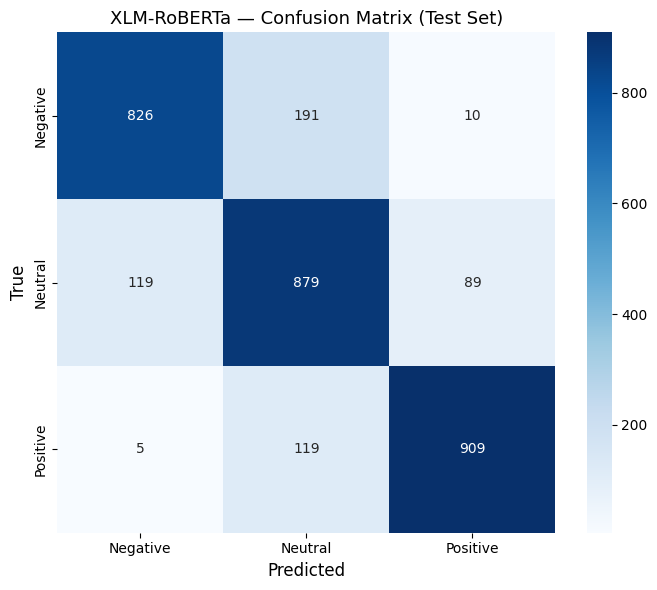

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/xlmr_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('XLM-RoBERTa — Confusion Matrix (Test Set)', fontsize=13)
plt.tight_layout()

save_path = f"{FIGURES}/xlmr_confusion_matrix.png"
fig.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved to {save_path}")

In [ ]:
# Build predictions DataFrame
test_df_out = df[df['split'] == 'test'][['review', 'label']].reset_index(drop=True)
test_df_out = test_df_out.rename(columns={'review': 'text', 'label': 'true_label'})
test_df_out['xlmr_pred'] = preds
test_df_out['xlmr_correct'] = (test_df_out['true_label'] == test_df_out['xlmr_pred']).astype(int)

pred_path = f"{OUTPUTS}/xlmr_predictions.csv"
test_df_out.to_csv(pred_path, index=False)

print(f"✓ Saved predictions to {pred_path}")
print(f"  Total: {len(test_df_out)}")
print(f"  Correct: {test_df_out['xlmr_correct'].sum()} ({test_df_out['xlmr_correct'].mean():.4f})")
print(f"\nSample:")
test_df_out.head()

✓ Saved predictions to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/xlmr_predictions.csv
  Total: 3147
  Correct: 2614 (0.8306)

Sample:


,text,true_label,xlmr_pred,xlmr_correct
0,okay naman kaso maliit size e adjust nyona lan...,1,1,1
1,good seller sends out photo before shipping ma...,2,2,1
2,di cya gano kabilis sa net loading and loading...,1,1,1
3,green ang order ko black ang dumating pero gre...,0,0,1
4,no scam po di deliver sa akin yunq parcel ko t...,0,0,1


### 6. Attention Visualization
Extract attention weights for 5 correctly classified and 5 misclassified reviews.  
Visualize which tokens XLM-R attends to, this feeds into RQ4b.

In [ ]:
# Separate correct and incorrect predictions
correct_mask = test_df_out['xlmr_correct'] == 1
incorrect_mask = test_df_out['xlmr_correct'] == 0

correct_df = test_df_out[correct_mask]
incorrect_df = test_df_out[incorrect_mask]

print(f"Correct predictions:   {len(correct_df)}")
print(f"Incorrect predictions: {len(incorrect_df)}")

# Pick 5 correct and 5 incorrect — try to get a mix of classes
np.random.seed(SEED)

correct_samples = pd.concat([
    correct_df[correct_df['true_label'] == 0].sample(2, random_state=SEED),
    correct_df[correct_df['true_label'] == 1].sample(1, random_state=SEED),
    correct_df[correct_df['true_label'] == 2].sample(2, random_state=SEED),
])

incorrect_samples = incorrect_df.sample(min(5, len(incorrect_df)), random_state=SEED)

curated = pd.concat([correct_samples, incorrect_samples]).reset_index(drop=True)
curated['category'] = ['correct'] * len(correct_samples) + ['incorrect'] * len(incorrect_samples)

print(f"\nCurated {len(curated)} examples for attention visualization:")
for i, row in curated.iterrows():
    snippet = row['text'][:80] + "..." if len(row['text']) > 80 else row['text']
    print(f"  [{row['category']:>9}] true={row['true_label']} pred={row['xlmr_pred']} | {snippet}")

Correct predictions:   2614
Incorrect predictions: 533

Curated 10 examples for attention visualization:
  [  correct] true=0 pred=0 | nice another overhyped tiktok product its doesn t last long and hindi naaamoy ng...
  [  correct] true=0 pred=0 | poor kung gusto niyo ng sakit ng ulo order kayo no sense of responsibility sent ...
  [  correct] true=1 pred=1 | red beetles order ko bakit iba dumating btw quality is ok for its price
  [  correct] true=2 pred=2 | matibay ang ganda po diku iniexpect salamat kasi umaabot sa pasko thank u seller...
  [  correct] true=2 pred=2 | sobrang ganda po ng items oorder ako ulit sa shop na ito nagustohan ng mga buyer...
  [incorrect] true=2 pred=1 | well packed naman po ang item sana magtagal sya magaan lang dya pero maganda nam...
  [incorrect] true=0 pred=1 | ok naman ganda siya kaso ang zipper niya pangit sira agad local zipper niya nang...
  [incorrect] true=1 pred=0 | 50 same scent with cloud 3rd time to order sa shop 1st time sa scent na ito im 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Attention-enabled model loaded with fine-tuned weights.


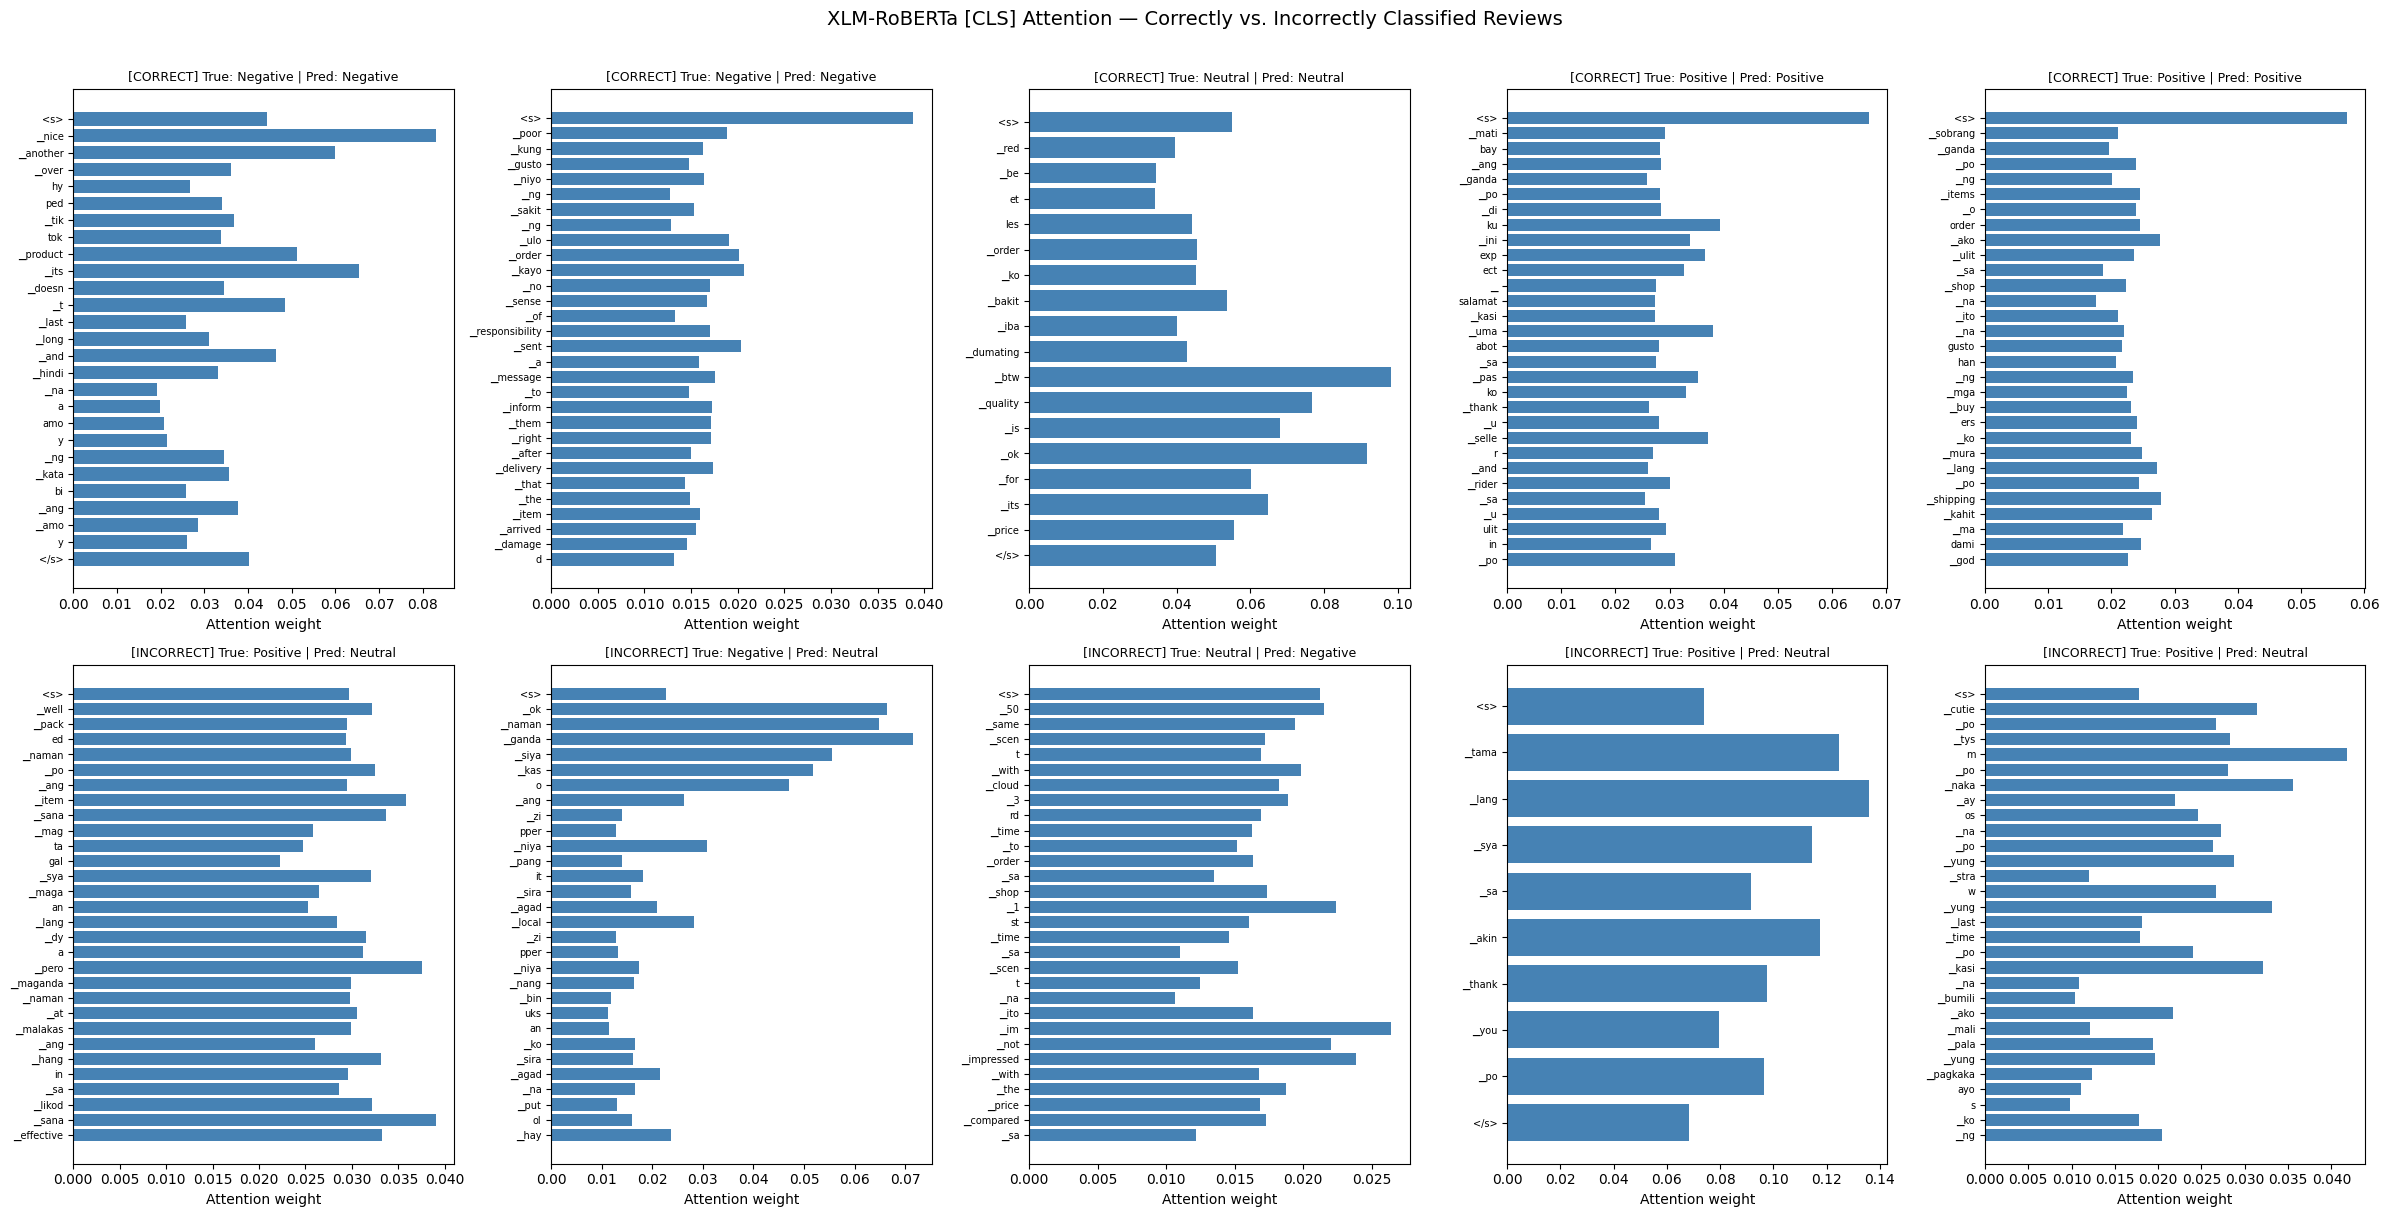

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/xlmr_attention_examples.png


In [ ]:
from transformers import AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import numpy as np

# Reload model with output_attentions enabled in config
attn_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    cache_dir=HF_CACHE,
    output_attentions=True,
)

# Load the fine-tuned weights from the trainer into this model
attn_model.load_state_dict(model.state_dict())
attn_model.to(device)
attn_model.eval()
print("✓ Attention-enabled model loaded with fine-tuned weights.")


def get_attention(text, tokenizer, model, device):
    """Extract attention weights for a single input text."""
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=128, padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions  # tuple: (num_layers,) each (1, heads, seq, seq)
    assert attentions is not None, "Attentions are None — check model config."

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Average across all heads in the last layer → (seq_len, seq_len)
    last_layer_attn = attentions[-1][0].mean(dim=0).cpu().numpy()

    # CLS token's attention over the sequence
    cls_attn = last_layer_attn[0]

    return tokens, cls_attn, last_layer_attn


def plot_cls_attention(tokens, cls_attn, title, ax):
    """Plot CLS token attention as a horizontal bar chart."""
    # Trim padding tokens
    non_pad = [i for i, t in enumerate(tokens) if t != '<pad>']
    tokens_trimmed = [tokens[i] for i in non_pad]
    attn_trimmed = [cls_attn[i] for i in non_pad]

    # Limit to first 30 tokens for readability
    max_show = 30
    tokens_show = tokens_trimmed[:max_show]
    attn_show = attn_trimmed[:max_show]

    y_pos = range(len(tokens_show))
    ax.barh(y_pos, attn_show, color='steelblue')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens_show, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Attention weight')
    ax.set_title(title, fontsize=9)


# Generate attention plots for all curated examples
n_examples = len(curated)
fig, axes = plt.subplots(2, 5, figsize=(24, 12))
axes = axes.flatten()

for i, (_, row) in enumerate(curated.iterrows()):
    if i >= 10:
        break
    tokens, cls_attn, _ = get_attention(row['text'], tokenizer, attn_model, device)

    true_lbl = label_names[row['true_label']]
    pred_lbl = label_names[row['xlmr_pred']]
    tag = row['category'].upper()
    title = f"[{tag}] True: {true_lbl} | Pred: {pred_lbl}"

    plot_cls_attention(tokens, cls_attn, title, axes[i])

# Hide unused subplots if fewer than 10 examples
for j in range(n_examples, 10):
    axes[j].axis('off')

plt.suptitle(
    "XLM-RoBERTa [CLS] Attention — Correctly vs. Incorrectly Classified Reviews",
    fontsize=14, y=1.01
)
plt.tight_layout()

save_path = f"{FIGURES}/xlmr_attention_examples.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

In [ ]:
import json

metadata = {
    "model": MODEL_NAME,
    "num_labels": 3,
    "epochs": 2,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "max_seq_length": 128,
    "seed": SEED,
    "train_samples": len(tokenized['train']),
    "test_samples": len(tokenized['test']),
    "training_time_minutes": round(train_time / 60, 1),
    "test_accuracy": round(acc, 4),
    "test_f1_weighted": round(f1_w, 4),
    "device": str(device),
    "gpu_name": torch.cuda.get_device_name(0) if device.type == "cuda" else "N/A",
}

meta_path = f"{OUTPUTS}/xlmr_training_metadata.json"
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("Training metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")
print(f"\n✓ Saved to {meta_path}")

Training metadata:
  model: xlm-roberta-base
  num_labels: 3
  epochs: 2
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  max_seq_length: 128
  seed: 42
  train_samples: 7340
  test_samples: 3147
  training_time_minutes: 6.6
  test_accuracy: 0.8306
  test_f1_weighted: 0.8319
  device: cuda
  gpu_name: Tesla T4

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/xlmr_training_metadata.json


---
# NOTEBOOK 04 - Comparison Analysis
---

# 04 - Comparison Analysis: Naive Bayes vs. XLM-RoBERTa
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa  
**Notebook owner:** Dan Angelo Erasquin (Manuscript Lead)  
**Summary:** Load both prediction files and build agreement matrix. Run McNemar's test (α = 0.05). Phenomenon-sliced error analysis. Final side-by-side comparison table. Cost/efficiency comparison

In [ ]:
import pandas as pd
import numpy as np

nb_df   = pd.read_csv(f"{OUTPUTS}/nb_predictions.csv")
xlmr_df = pd.read_csv(f"{OUTPUTS}/xlmr_predictions.csv")

# Verify alignment — both must have same test set in same order
assert len(nb_df) == len(xlmr_df), "Prediction files have different lengths!"
assert (nb_df['text'] == xlmr_df['text']).all(), "Text columns don't match — rows are misaligned!"
assert (nb_df['true_label'] == xlmr_df['true_label']).all(), "Labels don't match!"

print(f"✓ Both prediction files loaded and aligned. {len(nb_df)} test reviews.")
print(f"  NB accuracy:   {nb_df['nb_correct'].mean():.4f}")
print(f"  XLM-R accuracy: {xlmr_df['xlmr_correct'].mean():.4f}")

✓ Both prediction files loaded and aligned. 3147 test reviews.
  NB accuracy:   0.7909
  XLM-R accuracy: 0.8306


## 1. Agreement Matrix
For every test review, categorize into:
- **Both Correct** - both models got it right
- **NB Only** - NB correct, XLM-R wrong
- **XLM-R Only** - XLM-R correct, NB wrong
- **Both Wrong** - neither got it right

Agreement Matrix:
  Both Correct:  2271  (72.2%)
  NB Only:       218  (6.9%)
  XLM-R Only:    343  (10.9%)
  Both Wrong:    315  (10.0%)


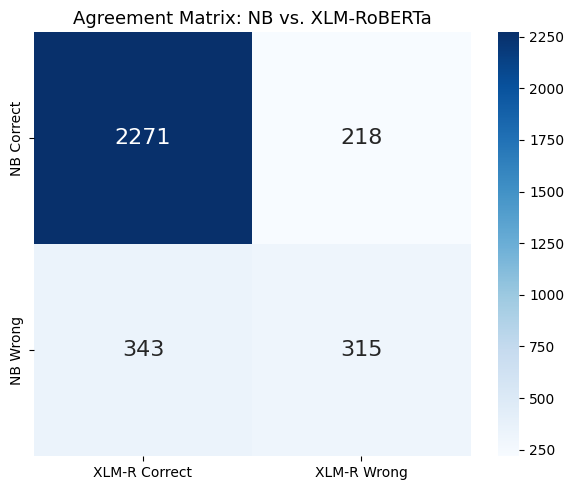

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/agreement_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge into one DataFrame
comp = pd.DataFrame({
    'text':        nb_df['text'],
    'true_label':  nb_df['true_label'],
    'nb_pred':     nb_df['nb_pred'],
    'xlmr_pred':   xlmr_df['xlmr_pred'],
    'nb_correct':  nb_df['nb_correct'],
    'xlmr_correct': xlmr_df['xlmr_correct'],
})

# Agreement categories
both_correct = ((comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 1)).sum()
nb_only      = ((comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 0)).sum()
xlmr_only    = ((comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 1)).sum()
both_wrong   = ((comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 0)).sum()

print("Agreement Matrix:")
print(f"  Both Correct:  {both_correct}  ({both_correct/len(comp)*100:.1f}%)")
print(f"  NB Only:       {nb_only}  ({nb_only/len(comp)*100:.1f}%)")
print(f"  XLM-R Only:    {xlmr_only}  ({xlmr_only/len(comp)*100:.1f}%)")
print(f"  Both Wrong:    {both_wrong}  ({both_wrong/len(comp)*100:.1f}%)")

# Visualize as heatmap
agreement = np.array([[both_correct, nb_only],
                       [xlmr_only, both_wrong]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agreement, annot=True, fmt='d', cmap='Blues',
            xticklabels=['XLM-R Correct', 'XLM-R Wrong'],
            yticklabels=['NB Correct', 'NB Wrong'],
            ax=ax, annot_kws={'size': 16})
ax.set_title('Agreement Matrix: NB vs. XLM-RoBERTa', fontsize=13)
plt.tight_layout()

save_path = f"{FIGURES}/agreement_matrix.png"
fig.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved to {save_path}")

## 2. McNemar's Test
Tests whether the two models have statistically different error rates on the same test set.  
Uses the off-diagonal cells of the agreement matrix (NB Only vs. XLM-R Only).  
- **H₀:** NB and XLM-R have equivalent classification performance.  
- **H₁:** XLM-R has statistically superior classification performance.  
- α = 0.05

In [ ]:
from scipy.stats import chi2

# McNemar's test using the off-diagonal cells
# b = NB correct, XLM-R wrong (nb_only)
# c = NB wrong, XLM-R correct (xlmr_only)
b = nb_only
c = xlmr_only

# McNemar's chi-squared statistic
if b + c == 0:
    print("No discordant pairs — models agree on every prediction.")
    mcnemar_stat = 0
    p_value = 1.0
else:
    mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value = 1 - chi2.cdf(mcnemar_stat, df=1)

print("=" * 55)
print("McNemar's Test: NB vs. XLM-RoBERTa")
print("=" * 55)
print(f"  Discordant cells:")
print(f"    NB correct, XLM-R wrong (b): {b}")
print(f"    NB wrong, XLM-R correct (c): {c}")
print(f"  Chi² statistic: {mcnemar_stat:.4f}")
print(f"  p-value:        {p_value:.6f}")
print(f"  α:              0.05")
print(f"  Decision:       {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")
print()

if p_value < 0.05:
    if c > b:
        print("  → XLM-R is statistically significantly better than NB.")
    else:
        print("  → NB is statistically significantly better than XLM-R.")
else:
    print("  → No statistically significant difference between the two models.")

# Also run scipy's built-in mcnemar for verification
from scipy.stats import contingency

# Build the 2x2 contingency table
table = np.array([[both_correct, nb_only],
                   [xlmr_only, both_wrong]])

# Use exact=False for chi-squared version
try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
    result = mcnemar_test(table, exact=False, correction=True)
    print(f"\n  Verification (statsmodels): stat={result.statistic:.4f}, p={result.pvalue:.6f}")
except ImportError:
    print("\n  (statsmodels not available for verification - manual calculation used)")

McNemar's Test: NB vs. XLM-RoBERTa
  Discordant cells:
    NB correct, XLM-R wrong (b): 218
    NB wrong, XLM-R correct (c): 343
  Chi² statistic: 27.4082
  p-value:        0.000000
  α:              0.05
  Decision:       Reject H₀

  → XLM-R is statistically significantly better than NB.

  Verification (statsmodels): stat=27.4082, p=0.000000


## 3. Side-by-Side Metrics Comparison
Full metrics table: accuracy, weighted F1, per-class P/R/F1 for both models.

Full Metrics Comparison: NB vs. XLM-RoBERTa
            Metric Naive Bayes XLM-RoBERTa
          Accuracy      0.7909      0.8306
       Weighted F1      0.7928      0.8319
                                          
Negative Precision      0.8165      0.8695
   Negative Recall      0.7624      0.8043
       Negative F1      0.7885      0.8356
 Neutral Precision      0.6891      0.7393
    Neutral Recall      0.7645      0.8086
        Neutral F1      0.7248      0.7724
Positive Precision      0.8910      0.9018
   Positive Recall      0.8470      0.8800
       Positive F1      0.8685      0.8907


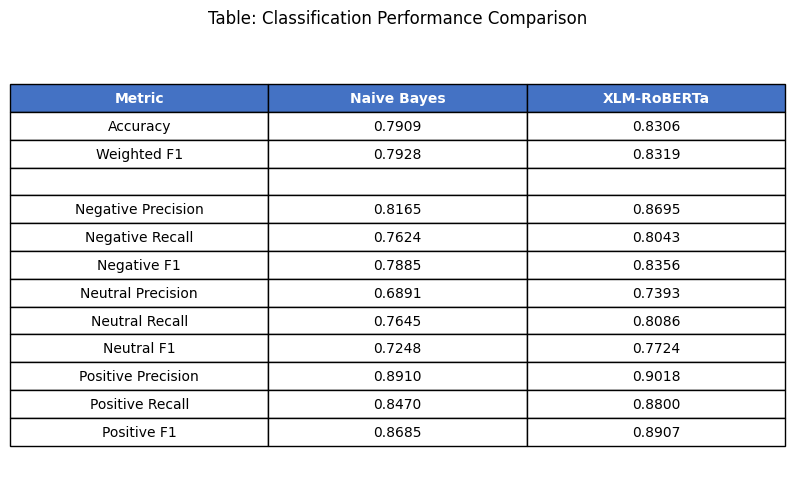

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/final_comparison_table.png


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report

label_names = ['Negative', 'Neutral', 'Positive']

# NB metrics
nb_acc = accuracy_score(comp['true_label'], comp['nb_pred'])
nb_f1w = f1_score(comp['true_label'], comp['nb_pred'], average='weighted')
nb_p, nb_r, nb_f1, _ = precision_recall_fscore_support(comp['true_label'], comp['nb_pred'], average=None)

# XLM-R metrics
xlmr_acc = accuracy_score(comp['true_label'], comp['xlmr_pred'])
xlmr_f1w = f1_score(comp['true_label'], comp['xlmr_pred'], average='weighted')
xlmr_p, xlmr_r, xlmr_f1, _ = precision_recall_fscore_support(comp['true_label'], comp['xlmr_pred'], average=None)

# Build comparison table
metrics_data = {
    'Metric': [
        'Accuracy', 'Weighted F1', '',
        'Negative Precision', 'Negative Recall', 'Negative F1',
        'Neutral Precision', 'Neutral Recall', 'Neutral F1',
        'Positive Precision', 'Positive Recall', 'Positive F1',
    ],
    'Naive Bayes': [
        f'{nb_acc:.4f}', f'{nb_f1w:.4f}', '',
        f'{nb_p[0]:.4f}', f'{nb_r[0]:.4f}', f'{nb_f1[0]:.4f}',
        f'{nb_p[1]:.4f}', f'{nb_r[1]:.4f}', f'{nb_f1[1]:.4f}',
        f'{nb_p[2]:.4f}', f'{nb_r[2]:.4f}', f'{nb_f1[2]:.4f}',
    ],
    'XLM-RoBERTa': [
        f'{xlmr_acc:.4f}', f'{xlmr_f1w:.4f}', '',
        f'{xlmr_p[0]:.4f}', f'{xlmr_r[0]:.4f}', f'{xlmr_f1[0]:.4f}',
        f'{xlmr_p[1]:.4f}', f'{xlmr_r[1]:.4f}', f'{xlmr_f1[1]:.4f}',
        f'{xlmr_p[2]:.4f}', f'{xlmr_r[2]:.4f}', f'{xlmr_f1[2]:.4f}',
    ],
}

metrics_table = pd.DataFrame(metrics_data)
print("=" * 55)
print("Full Metrics Comparison: NB vs. XLM-RoBERTa")
print("=" * 55)
print(metrics_table.to_string(index=False))

# Save as figure
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')
table_plot = ax.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc='center',
    loc='center',
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)
table_plot.scale(1.2, 1.5)

# Style header
for j in range(len(metrics_table.columns)):
    table_plot[0, j].set_facecolor('#4472C4')
    table_plot[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Table: Classification Performance Comparison', fontsize=12, pad=20)
plt.tight_layout()

save_path = f"{FIGURES}/final_comparison_table.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 4. Phenomenon-Sliced Error Analysis
The centerpiece of RQ4: compute per-slice accuracy for both models  
to identify which linguistic phenomena each model handles better or worse.

Slices from Data Person:
- Pragmatic markers: naman, lang, pa, na
- Slang: awit
- Negation: hindi, di, wala
- Short reviews (<10 tokens) / Long reviews (>50 tokens)
- Code-switching density: high_cs / low_cs

In [ ]:
# Load phenomenon slices
slices_df = pd.read_csv(f"{OUTPUTS}/phenomenon_slices.csv")

# Rename columns to match predictions files
slices_df = slices_df.rename(columns={'review': 'text', 'label': 'true_label'})

print(f"Phenomenon slices loaded: {len(slices_df)} rows")
print(f"Slices: {slices_df['slice_name'].unique()}")
print(f"Reviews per slice:")
print(slices_df['slice_name'].value_counts())

Phenomenon slices loaded: 8360 rows
Slices: ['marker_naman' 'marker_lang' 'marker_pa' 'marker_na' 'slang_awit'
 'negation_hindi' 'negation_di' 'negation_wala' 'short_reviews'
 'long_reviews' 'high_cs' 'low_cs']
Reviews per slice:
slice_name
high_cs           3050
marker_na         1427
marker_lang        899
marker_naman       765
marker_pa          554
negation_hindi     543
negation_di        440
short_reviews      256
negation_wala      213
long_reviews       111
low_cs              97
slang_awit           5
Name: count, dtype: int64


In [ ]:
# Merge predictions with slices
# A review can appear in multiple slices, so we merge on text + true_label
slices_with_preds = slices_df.merge(
    comp[['text', 'nb_pred', 'xlmr_pred', 'nb_correct', 'xlmr_correct']],
    on='text',
    how='inner'
)

unmatched = len(slices_df) - len(slices_with_preds)
if unmatched > 0:
    print(f"⚠ {unmatched} slice rows did not match a prediction row (possibly train-set reviews).")
    print(f"  Matched: {len(slices_with_preds)} / {len(slices_df)}")
else:
    print(f"✓ All {len(slices_with_preds)} slice rows matched.")

# Compute per-slice metrics
slice_results = []

for slice_name in sorted(slices_with_preds['slice_name'].unique()):
    subset = slices_with_preds[slices_with_preds['slice_name'] == slice_name]
    n = len(subset)
    nb_acc = subset['nb_correct'].mean()
    xlmr_acc = subset['xlmr_correct'].mean()
    diff = xlmr_acc - nb_acc

    slice_results.append({
        'Slice': slice_name,
        'N': n,
        'NB Accuracy': f'{nb_acc:.4f}',
        'XLM-R Accuracy': f'{xlmr_acc:.4f}',
        'Δ (XLM-R − NB)': f'{diff:+.4f}',
        'nb_acc_raw': nb_acc,
        'xlmr_acc_raw': xlmr_acc,
    })

slice_table = pd.DataFrame(slice_results)

# Add overall row for reference
overall_nb = comp['nb_correct'].mean()
overall_xlmr = comp['xlmr_correct'].mean()
overall_row = pd.DataFrame([{
    'Slice': '** OVERALL **',
    'N': len(comp),
    'NB Accuracy': f'{overall_nb:.4f}',
    'XLM-R Accuracy': f'{overall_xlmr:.4f}',
    'Δ (XLM-R − NB)': f'{overall_xlmr - overall_nb:+.4f}',
    'nb_acc_raw': overall_nb,
    'xlmr_acc_raw': overall_xlmr,
}])

slice_table_display = pd.concat([slice_table, overall_row], ignore_index=True)

print("\n" + "=" * 75)
print("Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa")
print("=" * 75)
print(slice_table_display[['Slice', 'N', 'NB Accuracy', 'XLM-R Accuracy', 'Δ (XLM-R − NB)']].to_string(index=False))

✓ All 8360 slice rows matched.

Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa
         Slice    N NB Accuracy XLM-R Accuracy Δ (XLM-R − NB)
       high_cs 3050      0.7898         0.8279        +0.0380
  long_reviews  111      0.7658         0.8018        +0.0360
        low_cs   97      0.8247         0.9175        +0.0928
   marker_lang  899      0.7753         0.8242        +0.0489
     marker_na 1427      0.7926         0.8199        +0.0273
  marker_naman  765      0.7712         0.8222        +0.0510
     marker_pa  554      0.7924         0.8339        +0.0415
   negation_di  440      0.7523         0.8318        +0.0795
negation_hindi  543      0.7256         0.7919        +0.0663
 negation_wala  213      0.7981         0.8216        +0.0235
 short_reviews  256      0.7969         0.8438        +0.0469
    slang_awit    5      0.6000         0.8000        +0.2000
 ** OVERALL ** 3147      0.7909         0.8306        +0.0397


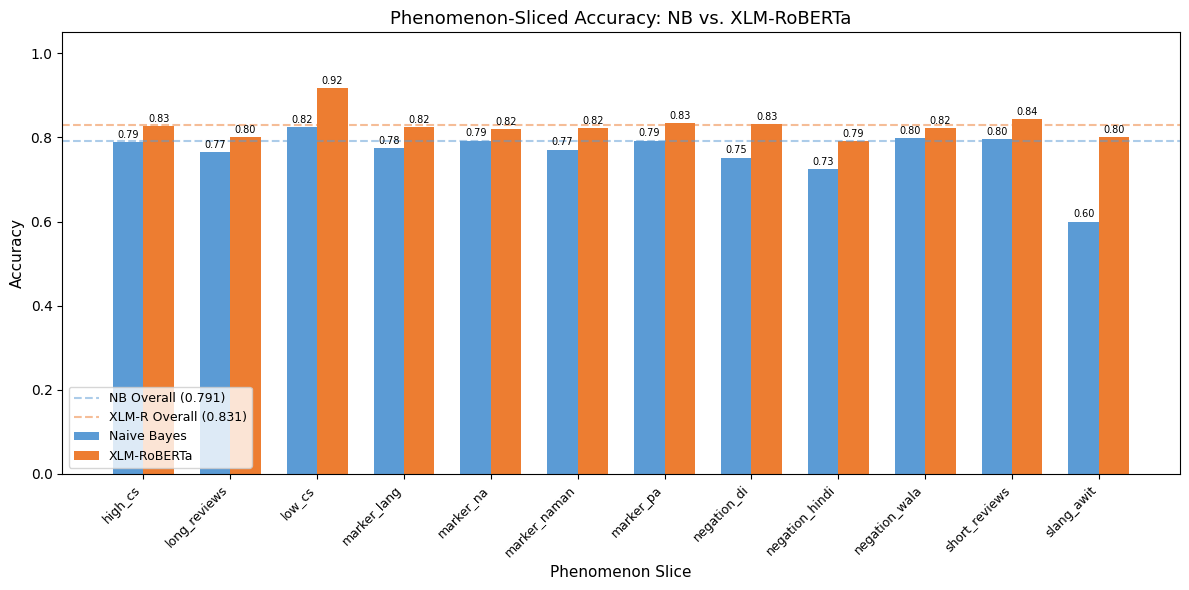

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/phenomenon_slice_comparison.png


In [ ]:
# Bar chart comparing NB vs XLM-R accuracy per slice
slice_plot = slice_table.copy()  # Without the overall row

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(slice_plot))
width = 0.35

bars_nb   = ax.bar(x - width/2, slice_plot['nb_acc_raw'],   width, label='Naive Bayes', color='#5B9BD5')
bars_xlmr = ax.bar(x + width/2, slice_plot['xlmr_acc_raw'], width, label='XLM-RoBERTa', color='#ED7D31')

# Add overall accuracy as reference lines
ax.axhline(y=overall_nb,   color='#5B9BD5', linestyle='--', alpha=0.5, label=f'NB Overall ({overall_nb:.3f})')
ax.axhline(y=overall_xlmr, color='#ED7D31', linestyle='--', alpha=0.5, label=f'XLM-R Overall ({overall_xlmr:.3f})')

ax.set_xlabel('Phenomenon Slice', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(slice_plot['Slice'], rotation=45, ha='right', fontsize=9)
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 1.05)

# Add value labels on bars
for bar in bars_nb:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)
for bar in bars_xlmr:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)

plt.tight_layout()

save_path = f"{FIGURES}/phenomenon_slice_comparison.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 5. Error Pattern Deep Dive
Examine the "Both Wrong" and "Model-specific error" cases  
to understand qualitative failure patterns.

In [ ]:
# Tag each review with its agreement category
comp['agreement'] = 'both_correct'
comp.loc[(comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 0), 'agreement'] = 'nb_only'
comp.loc[(comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 1), 'agreement'] = 'xlmr_only'
comp.loc[(comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 0), 'agreement'] = 'both_wrong'

label_names = ['Negative', 'Neutral', 'Positive']

# Show class breakdown of each agreement category
print("Class distribution within each agreement category:")
print("=" * 60)
for cat in ['nb_only', 'xlmr_only', 'both_wrong']:
    subset = comp[comp['agreement'] == cat]
    print(f"\n{cat.upper()} ({len(subset)} reviews):")
    for lbl in [0, 1, 2]:
        count = (subset['true_label'] == lbl).sum()
        print(f"  {label_names[lbl]}: {count} ({count/len(subset)*100:.1f}%)")

# Sample reviews from each category
print("\n" + "=" * 60)
print("Sample reviews — NB CORRECT, XLM-R WRONG:")
print("=" * 60)
nb_only_samples = comp[comp['agreement'] == 'nb_only'].sample(min(5, nb_only), random_state=42)
for _, row in nb_only_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

print("=" * 60)
print("Sample reviews — XLM-R CORRECT, NB WRONG:")
print("=" * 60)
xlmr_only_samples = comp[comp['agreement'] == 'xlmr_only'].sample(min(5, xlmr_only), random_state=42)
for _, row in xlmr_only_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

print("=" * 60)
print("Sample reviews — BOTH WRONG:")
print("=" * 60)
both_wrong_samples = comp[comp['agreement'] == 'both_wrong'].sample(min(5, both_wrong), random_state=42)
for _, row in both_wrong_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

Class distribution within each agreement category:

NB_ONLY (218 reviews):
  Negative: 92 (42.2%)
  Neutral: 88 (40.4%)
  Positive: 38 (17.4%)

XLMR_ONLY (343 reviews):
  Negative: 135 (39.4%)
  Neutral: 136 (39.7%)
  Positive: 72 (21.0%)

BOTH_WRONG (315 reviews):
  Negative: 109 (34.6%)
  Neutral: 120 (38.1%)
  Positive: 86 (27.3%)

Sample reviews — NB CORRECT, XLM-R WRONG:
  True: Negative | NB: Negative | XLM-R: Neutral
  "free wifi pero napaka bagal walang kwenta internet connection dito..."

  True: Neutral | NB: Neutral | XLM-R: Positive
  "wala na finish na di ko inexpect yung ganda ng quality hindi sobrang kapal hindi rin sobrang nipis tska kapag sinuot sob..."

  True: Positive | NB: Positive | XLM-R: Neutral
  "maganda ung tela makapal at tama lahat ng sizes mabuti ito tama lahat pakicheck po ng mga sizes at colors bago nu po ish..."

  True: Neutral | NB: Neutral | XLM-R: Negative
  "hindi ko alam kung sa driver ba o sa mismong seller ang may problema sira ung saksakan adap

## 6. Cost & Efficiency Comparison
Training time, model size, inference speed, interpretability — the practical trade-offs (RQ4d).

Cost & Efficiency Comparison
           Metric                           Naive Bayes                       XLM-RoBERTa
    Training time                           < 5 seconds                      ~6.6 minutes
Model size (disk)              < 10 MB (TF-IDF + model)              ~1.1 GB (full model)
       Parameters                V features × 3 classes                             ~278M
     Requires GPU                         No (CPU only)                    Yes (Tesla T4)
 Interpretability High (top features directly readable) Low (requires attention analysis)


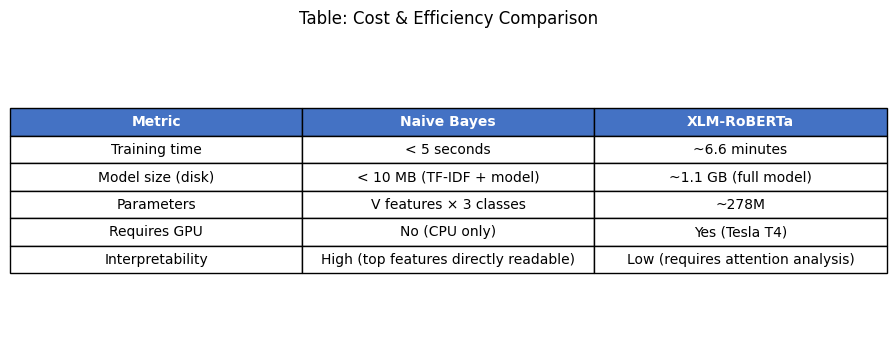

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/cost_comparison.png


In [ ]:
import json

# Load XLM-R metadata
with open(f"{OUTPUTS}/xlmr_training_metadata.json", 'r') as f:
    xlmr_meta = json.load(f)

# NB training is near-instant; estimate from typical runs
# (NB person can update these if they logged exact times)
cost_data = {
    'Metric': [
        'Training time',
        'Model size (disk)',
        'Parameters',
        'Requires GPU',
        'Interpretability',
    ],
    'Naive Bayes': [
        '< 5 seconds',
        '< 10 MB (TF-IDF + model)',
        'V features × 3 classes',
        'No (CPU only)',
        'High (top features directly readable)',
    ],
    'XLM-RoBERTa': [
        f'~{xlmr_meta.get("training_time_minutes", "N/A")} minutes',
        '~1.1 GB (full model)',
        '~278M',
        f'Yes ({xlmr_meta.get("gpu_name", "T4 GPU")})',
        'Low (requires attention analysis)',
    ],
}

cost_table = pd.DataFrame(cost_data)
print("=" * 65)
print("Cost & Efficiency Comparison")
print("=" * 65)
print(cost_table.to_string(index=False))

# Save as figure
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis('off')
table_plot = ax.table(
    cellText=cost_table.values,
    colLabels=cost_table.columns,
    cellLoc='center',
    loc='center',
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)
table_plot.scale(1.2, 1.6)

for j in range(len(cost_table.columns)):
    table_plot[0, j].set_facecolor('#4472C4')
    table_plot[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Table: Cost & Efficiency Comparison', fontsize=12, pad=20)
plt.tight_layout()

save_path = f"{FIGURES}/cost_comparison.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 7. Summary of Findings

Key results to carry into the manuscript:
1. **Overall performance gap:** NB vs XLM-R accuracy and F1
2. **McNemar's test:** statistically significant difference?
3. **Phenomenon slices:** which slices show the largest/smallest gap?
4. **Agreement patterns:** what fraction of reviews do both models get right/wrong?
5. **Cost trade-off:** orders-of-magnitude difference in compute for how much accuracy?

In [ ]:
print("=" * 65)
print("NOTEBOOK 04 — RESULTS SUMMARY FOR MANUSCRIPT")
print("=" * 65)

print(f"\n1. OVERALL PERFORMANCE")
print(f"   NB Accuracy:     {overall_nb:.4f}")
print(f"   XLM-R Accuracy:  {overall_xlmr:.4f}")
print(f"   Δ:               {overall_xlmr - overall_nb:+.4f}")

print(f"\n2. McNEMAR'S TEST")
print(f"   Chi²: {mcnemar_stat:.4f}   p = {p_value:.6f}")
print(f"   Decision: {'Reject H₀ — significant difference' if p_value < 0.05 else 'Fail to reject H₀'}")

print(f"\n3. AGREEMENT MATRIX")
print(f"   Both correct:  {both_correct} ({both_correct/len(comp)*100:.1f}%)")
print(f"   NB only:       {nb_only} ({nb_only/len(comp)*100:.1f}%)")
print(f"   XLM-R only:    {xlmr_only} ({xlmr_only/len(comp)*100:.1f}%)")
print(f"   Both wrong:    {both_wrong} ({both_wrong/len(comp)*100:.1f}%)")

print(f"\n4. PHENOMENON SLICES — LARGEST XLM-R ADVANTAGE")
slice_table_sorted = slice_table.copy()
slice_table_sorted['diff'] = slice_table_sorted['xlmr_acc_raw'] - slice_table_sorted['nb_acc_raw']
for _, row in slice_table_sorted.nlargest(3, 'diff').iterrows():
    print(f"   {row['Slice']:20s}  NB={row['nb_acc_raw']:.3f}  XLM-R={row['xlmr_acc_raw']:.3f}  Δ={row['diff']:+.3f}")

print(f"\n   SMALLEST GAP (or NB advantage)")
for _, row in slice_table_sorted.nsmallest(3, 'diff').iterrows():
    print(f"   {row['Slice']:20s}  NB={row['nb_acc_raw']:.3f}  XLM-R={row['xlmr_acc_raw']:.3f}  Δ={row['diff']:+.3f}")

print(f"\n5. FILES SAVED")
print(f"   {FIGURES}/agreement_matrix.png")
print(f"   {FIGURES}/phenomenon_slice_comparison.png")
print(f"   {FIGURES}/final_comparison_table.png")
print(f"   {FIGURES}/cost_comparison.png")

NOTEBOOK 04 — RESULTS SUMMARY FOR MANUSCRIPT

1. OVERALL PERFORMANCE
   NB Accuracy:     0.7909
   XLM-R Accuracy:  0.8306
   Δ:               +0.0397

2. McNEMAR'S TEST
   Chi²: 27.4082   p = 0.000000
   Decision: Reject H₀ — significant difference

3. AGREEMENT MATRIX
   Both correct:  2271 (72.2%)
   NB only:       218 (6.9%)
   XLM-R only:    343 (10.9%)
   Both wrong:    315 (10.0%)

4. PHENOMENON SLICES — LARGEST XLM-R ADVANTAGE
   slang_awit            NB=0.600  XLM-R=0.800  Δ=+0.200
   low_cs                NB=0.825  XLM-R=0.918  Δ=+0.093
   negation_di           NB=0.752  XLM-R=0.832  Δ=+0.080

   SMALLEST GAP (or NB advantage)
   negation_wala         NB=0.798  XLM-R=0.822  Δ=+0.023
   marker_na             NB=0.793  XLM-R=0.820  Δ=+0.027
   long_reviews          NB=0.766  XLM-R=0.802  Δ=+0.036

5. FILES SAVED
   /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/agreement_matrix.png
   /content/d

## END

*fin*